In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
#차트에서 한글파일 깨질때

import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/한국교통안전공단_자동차결함 리콜현황_20201231.csv',
                   encoding='cp949')
data.head()

,제작자,차명,생산기간,생산기간.1,리콜개시일,리콜사유
0,(주)에프엠케이,기블리 디젤,2014-05-28,2016-03-15,2020-03-23,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...
1,(주)에프엠케이,콰트로포르테 디젤,2014-05-08,2016-03-14,2020-03-23,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...
2,한국토요타자동차(주),토요타 프리우스,2019-07-11,2019-07-31,2020-01-23,"콤비네이션 미터(계기판) 내부 기판의 생산 설비 관리가 부적절하여, 기판의 회로부품..."
3,한국토요타자동차(주),토요타 캠리,2019-08-23,2019-09-06,2020-01-23,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부..."
4,한국토요타자동차(주),토요타 캠리 하이브리드,2019-08-21,2019-09-04,2020-01-23,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부..."


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   제작자     1275 non-null   object
 1   차명      1275 non-null   object
 2   생산기간    1275 non-null   object
 3   생산기간.1  1275 non-null   object
 4   리콜개시일   1275 non-null   object
 5   리콜사유    1275 non-null   object
dtypes: object(6)
memory usage: 59.9+ KB


In [ ]:
data.describe()

,제작자,차명,생산기간,생산기간.1,리콜개시일,리콜사유
count,1275,1275,1275,1275,1275,1275
unique,34,639,921,891,134,240
top,비엠더블유코리아(주),BMW 320d,2019-08-02,2013-06-28,2020-06-01,당사는 당사의 EGR 쿨러가 이전 리콜 대상 EGR 쿨러에 비하여 개선되고 최적화 ...
freq,527,15,9,10,120,239


In [ ]:
data.isnull().sum()

,0
제작자,0
차명,0
생산기간,0
생산기간.1,0
리콜개시일,0
리콜사유,0


In [ ]:
# 중복값 확인
data[data.duplicated(keep=False)]

,제작자,차명,생산기간,생산기간.1,리콜개시일,리콜사유
34,비엠더블유코리아(주),BMW 316i,2001-01-09,2001-01-09,2020-02-07,차량이 고온 다습한 지역에 장기간 노출 되었을 때 에어백 인플레이터 내부 압축가스 ...
82,비엠더블유코리아(주),BMW 316i,2001-01-09,2001-01-09,2020-02-07,차량이 고온 다습한 지역에 장기간 노출 되었을 때 에어백 인플레이터 내부 압축가스 ...


In [ ]:
data = data.drop_duplicates()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1274
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   제작자     1274 non-null   object
 1   차명      1274 non-null   object
 2   생산기간    1274 non-null   object
 3   생산기간.1  1274 non-null   object
 4   리콜개시일   1274 non-null   object
 5   리콜사유    1274 non-null   object
dtypes: object(6)
memory usage: 69.7+ KB


In [ ]:
# 생산기간 , 생산기간1 , 리콜게시일의 연도, 월, 일 각각 정수형으로 변환

def parse_year(s):
  return int(s[:4])

def parse_month(s):
  return int(s[5:7])

def parse_day(s):
  return int(s[8:])

data['start_year'] =data['생산기간'].apply(parse_year)
data['start_month'] =data['생산기간'].apply(parse_month)
data['start_day'] =data['생산기간'].apply(parse_day)

data['end_year'] =data['생산기간.1'].apply(parse_year)
data['end_month'] =data['생산기간.1'].apply(parse_month)
data['end_day'] =data['생산기간.1'].apply(parse_day)

data['recall_year'] =data['리콜개시일'].apply(parse_year)
data['recall_month'] =data['리콜개시일'].apply(parse_month)
data['recall_day'] =data['리콜개시일'].apply(parse_day)

In [ ]:
data.drop(columns=['생산기간','생산기간.1','리콜개시일'],inplace=True)
data.head()

,제작자,차명,리콜사유,start_year,start_month,start_day,end_year,end_month,end_day,recall_year,recall_month,recall_day
0,(주)에프엠케이,기블리 디젤,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...,2014,5,28,2016,3,15,2020,3,23
1,(주)에프엠케이,콰트로포르테 디젤,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...,2014,5,8,2016,3,14,2020,3,23
2,한국토요타자동차(주),토요타 프리우스,"콤비네이션 미터(계기판) 내부 기판의 생산 설비 관리가 부적절하여, 기판의 회로부품...",2019,7,11,2019,7,31,2020,1,23
3,한국토요타자동차(주),토요타 캠리,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부...",2019,8,23,2019,9,6,2020,1,23
4,한국토요타자동차(주),토요타 캠리 하이브리드,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부...",2019,8,21,2019,9,4,2020,1,23


In [ ]:
# 리콜 개시한 년도
data.recall_year.min(),data.recall_year.max()

(2019, 2020)

In [ ]:
# 리콜 2020년도 데이터
data=data[data["recall_year"]==2020]
len(data)

1263

In [ ]:
data.groupby('제작자').count()['차명'].sort_values(ascending=False)

,차명
제작자,
비엠더블유코리아(주),526
메르세데스벤츠코리아(주),234
아우디폭스바겐코리아(주),115
한불모터스(주),71
한국토요타자동차(주),54
(주)볼보자동차코리아,39
현대자동차(주),28
기아자동차(주),19
(주) 한국모터트레이딩,16


/tmp/ipython-input-4158893482.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='제작자',data=data,palette='Set2',order=tmp.index)


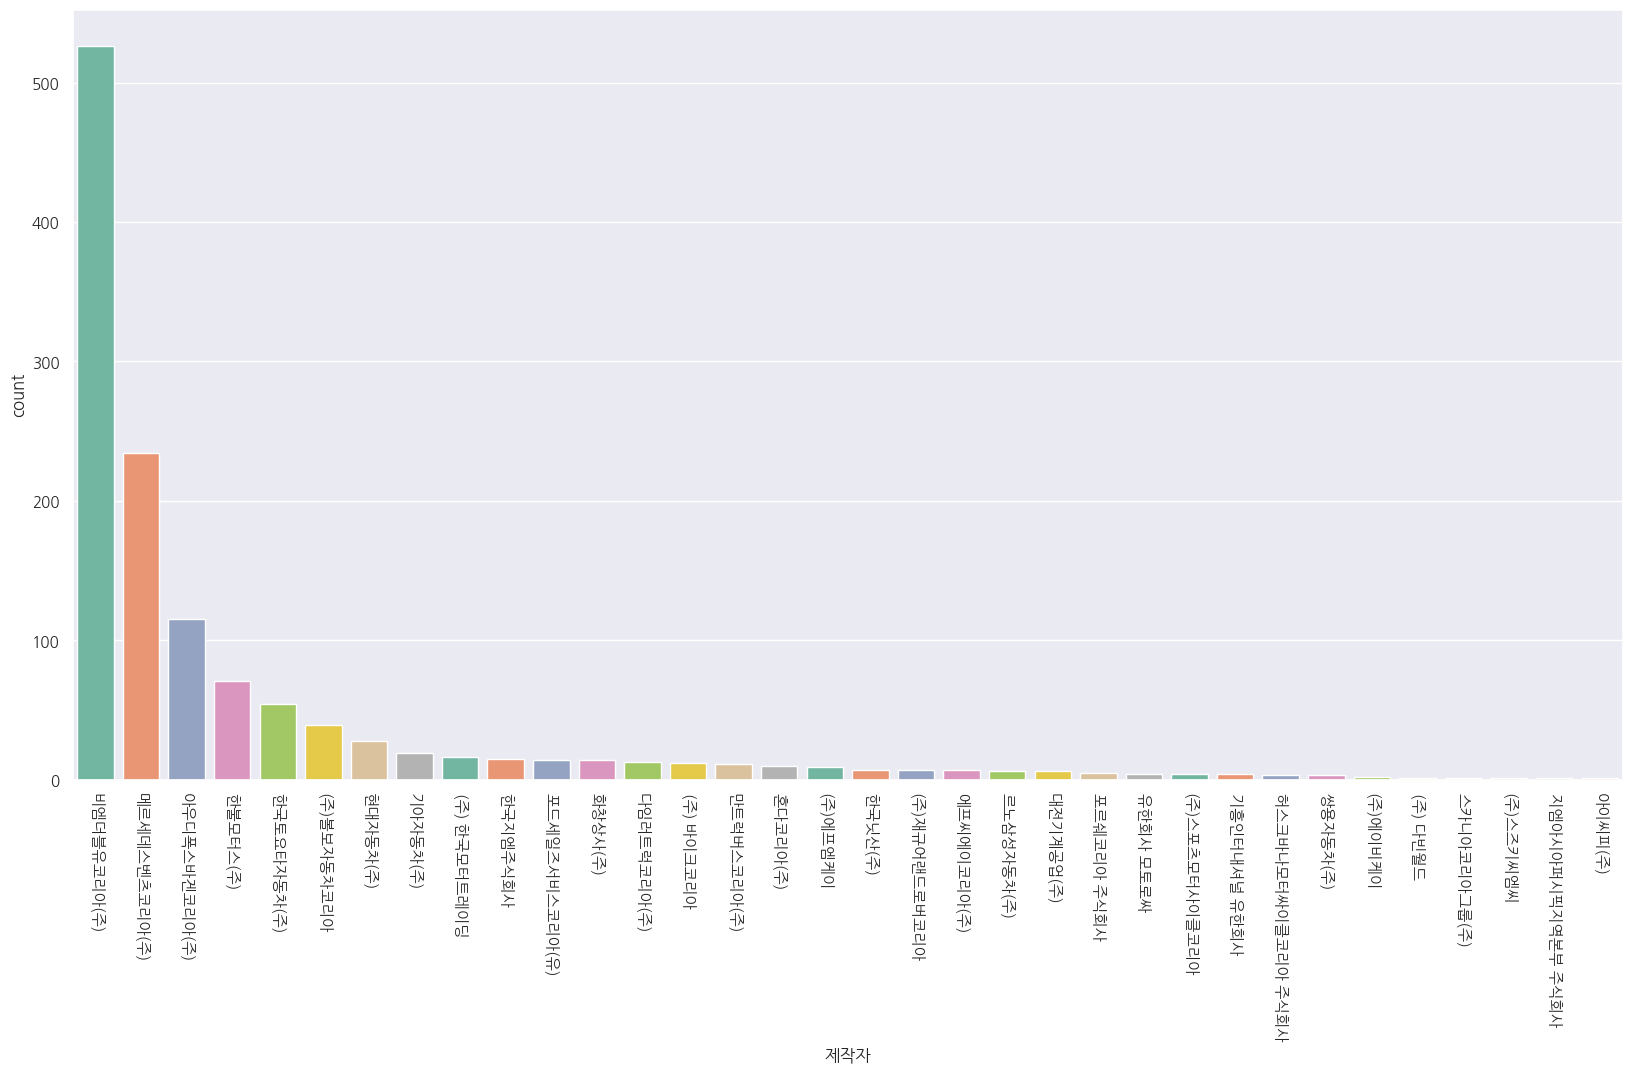

In [ ]:
tmp = pd.DataFrame(data.groupby('제작자').count()['차명'].sort_values(ascending=False))

plt.figure(figsize=(20,10))
sns.set(font='NanumGothic',rc={'axes.unicode_minus':False},
        style='darkgrid')
ax = sns.countplot(x='제작자',data=data,palette='Set2',order=tmp.index)
plt.xticks(rotation=270)
plt.show()

/tmp/ipython-input-3603938943.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='차명',data=data,palette='Set2',order=tmp.index)


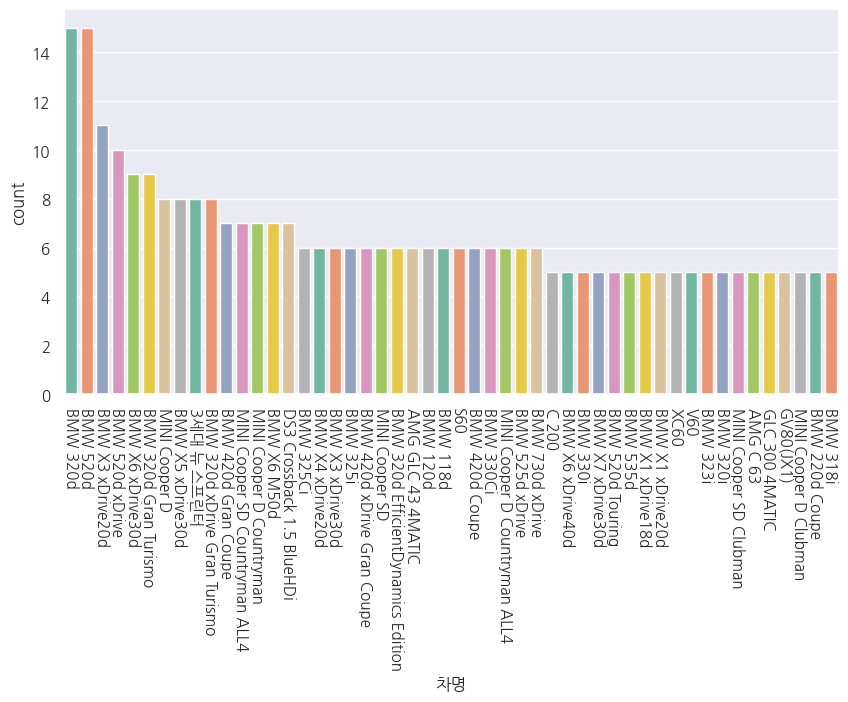

In [ ]:
# 모델명

tmp = pd.DataFrame(data.groupby('차명').count()['start_year'].sort_values(ascending=False))
tmp = tmp.rename(columns={'제작자':'count'}).iloc[:50]

plt.figure(figsize=(10,5))
sns.set(font='NanumGothic',rc={'axes.unicode_minus':False},
        style='darkgrid')
ax = sns.countplot(x='차명',data=data,palette='Set2',order=tmp.index)
plt.xticks(rotation=270)
plt.show()

/tmp/ipython-input-3258219456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='recall_month',data=data,palette='Set2')


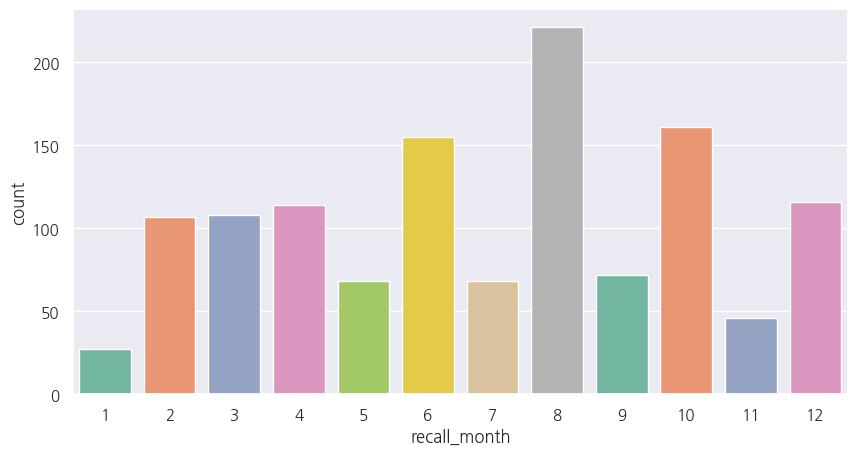

In [ ]:
# 모델명

plt.figure(figsize=(10,5))
sns.set(font='NanumGothic',rc={'axes.unicode_minus':False},
        style='darkgrid')
ax = sns.countplot(x='recall_month',data=data,palette='Set2')
plt.show()

In [ ]:
data.head()

,제작자,차명,리콜사유,start_year,start_month,start_day,end_year,end_month,end_day,recall_year,recall_month,recall_day
0,(주)에프엠케이,기블리 디젤,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...,2014,5,28,2016,3,15,2020,3,23
1,(주)에프엠케이,콰트로포르테 디젤,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...,2014,5,8,2016,3,14,2020,3,23
2,한국토요타자동차(주),토요타 프리우스,"콤비네이션 미터(계기판) 내부 기판의 생산 설비 관리가 부적절하여, 기판의 회로부품...",2019,7,11,2019,7,31,2020,1,23
3,한국토요타자동차(주),토요타 캠리,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부...",2019,8,23,2019,9,6,2020,1,23
4,한국토요타자동차(주),토요타 캠리 하이브리드,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부...",2019,8,21,2019,9,4,2020,1,23


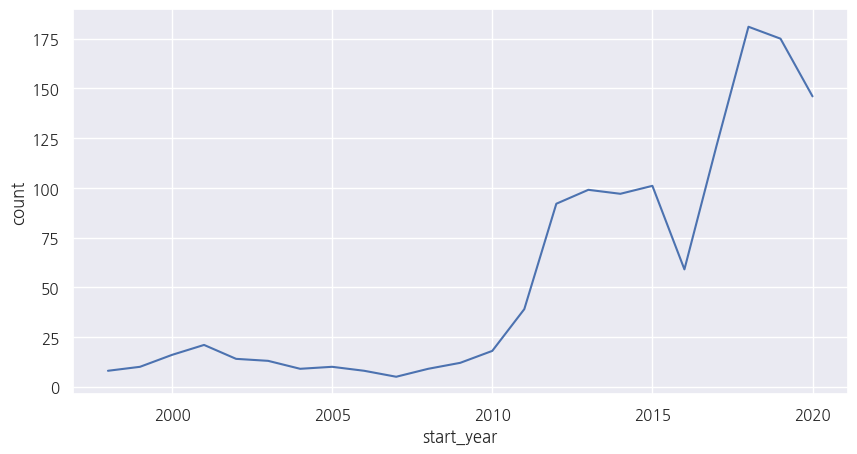

In [ ]:
# 생산년도별 lineplot

tmp = pd.DataFrame(data.groupby('start_year').count()['차명']).rename(
    columns={'차명':'count'}).reset_index()

plt.figure(figsize=(10,5))
sns.set(font='NanumGothic',rc={'axes.unicode_minus':False},
        style='darkgrid')
sns.lineplot(data=tmp,x='start_year',y='count')
plt.show()

In [ ]:
# 2020년에 리콜 개시가 가장 많이 일어난 달과 가장 적에 일어난 달의 차이

tmp = pd.DataFrame(data.groupby('recall_month').count()['start_year'].sort_values(ascending=False))

print(tmp.iloc[0]['start_year'] - tmp.iloc[-1]['start_year'])

194


/tmp/ipython-input-3683270875.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='제작자',data=tmp,palette='Set2')


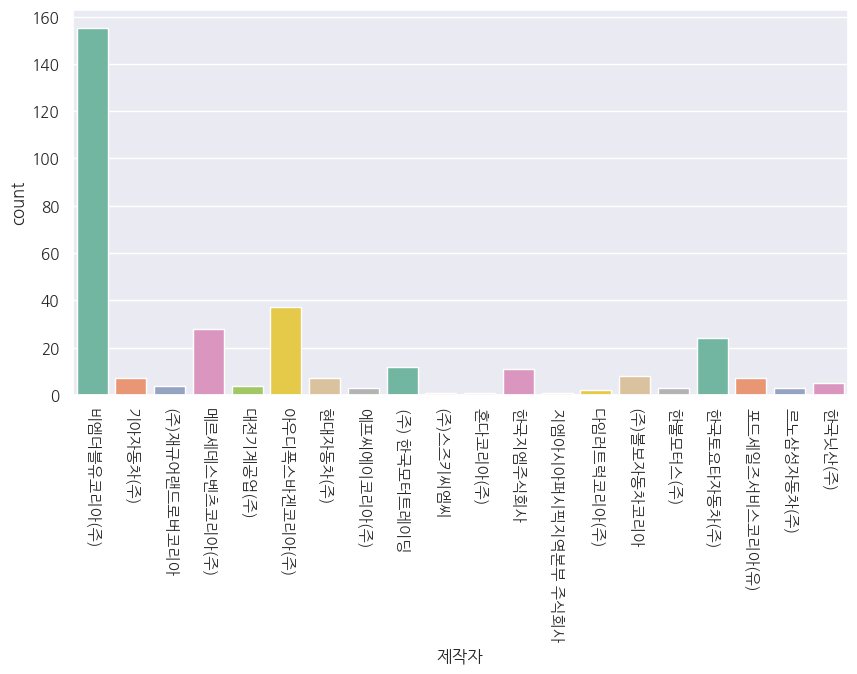

In [ ]:
# 2020년 4분기(10월,11월,12월) 제작별 리콜 현황 시각화
# recall_month가 10,11,12인 데이터만 추출

tmp = data[data.recall_month.isin([10,11,12])]

plt.figure(figsize=(10,5))
sns.set(font='NanumGothic',rc={'axes.unicode_minus':False},
        style='darkgrid')
sns.countplot(x='제작자',data=tmp,palette='Set2')
plt.xticks(rotation=270)
plt.show()


/tmp/ipython-input-3938556229.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='start_year',data=tmp,palette='Set2')


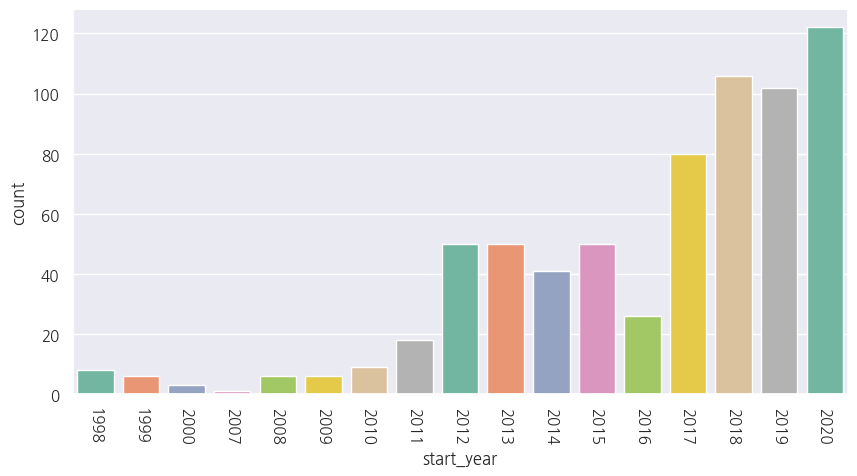

In [ ]:
# 2020년 하반기(7~12) 리콜 생산개시 연도별 시각화

tmp = data[data.recall_month.isin([7,8,9,10,11,12])]
# tmp = data[data.recall_month>=7]

plt.figure(figsize=(10,5))
sns.set(font='NanumGothic',rc={'axes.unicode_minus':False},
        style='darkgrid')
sns.countplot(x='start_year',data=tmp,palette='Set2')
plt.xticks(rotation=270)
plt.show()

In [200]:
from wordcloud import WordCloud,STOPWORDS
set(STOPWORDS)

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [201]:
spwords= set(["동안", "인하여", "있는", "경우", "있습니다", "가능성이", "않을", "차량의",
              "가", "에","될", "이", "인해", "수", "중", "시", "또는", "있음", "의",
              "및", "있으며", "발생할", "이로", "오류로", "해당", "매우"])

In [206]:
# 리콜 사유에 해당하는 열의 값들을 중복을 제거 한 뒤에 이어붙여서 text라는 문자열에 삽입

text = ""

for i in data.리콜사유.drop_duplicates():
  text = text + i
text[:100]

'스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑 & 고) 2) 결함 원인 : 오토 스타트 결함(스탑&고 작동 시 재시동 불가 현상)은 과도한 전'

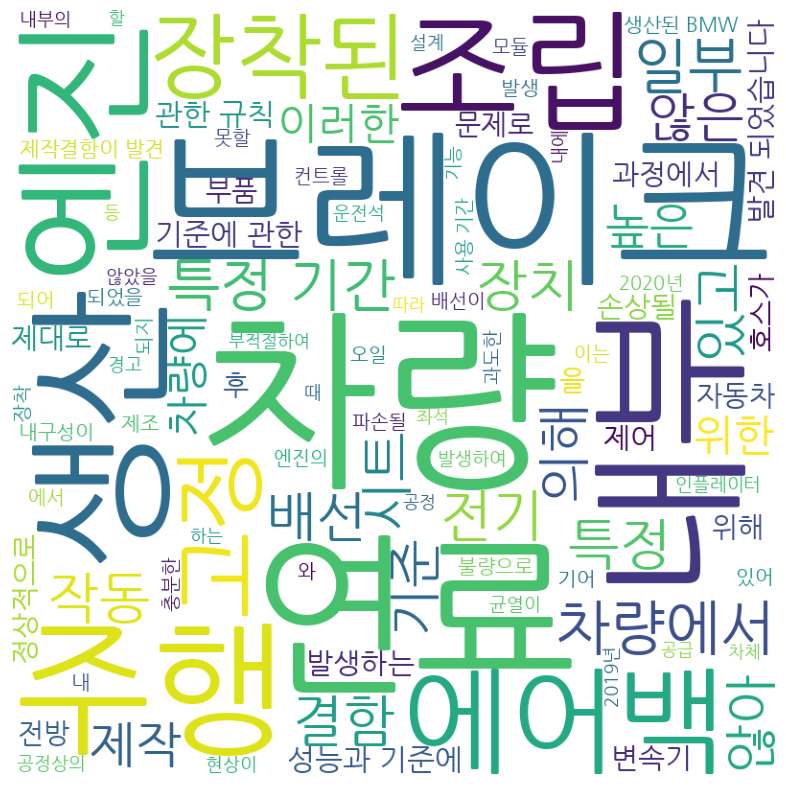

In [208]:
wc1 = WordCloud(max_font_size=200,stopwords=spwords,max_words=100,
                font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                background_color='white',width=800,height=800)

wc1.generate(text)
plt.figure(figsize=(10,8))
plt.imshow(wc1)
plt.tight_layout(pad=0)
plt.axis('off')
plt.show()

In [211]:
spwords= set(["동안", "인하여", "있는", "경우", "있습니다", "가능성이", "않을", "차량의",'에서','제조','위한','때','되지',
              "가", "에","될", "이", "인해", "수", "중", "시", "또는", "있음", "의",'와','못할','할','내부의','발견 되었습니다.',
              "및", "있으며", "발생할", "이로", "오류로", "해당","매우",'않아','내','있어','자체','발생하여','충분한','하는'])

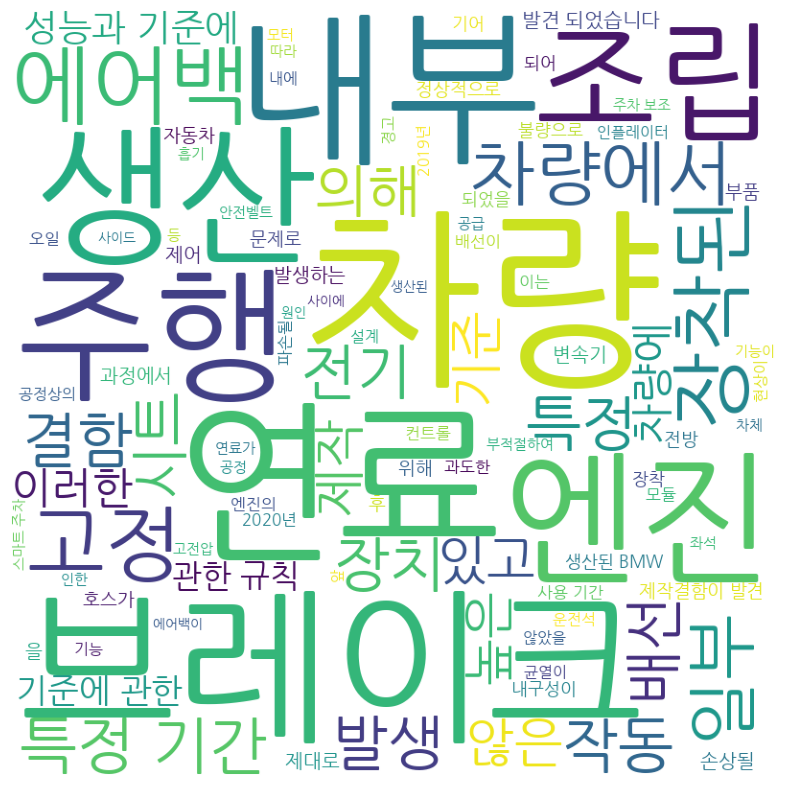

In [212]:
wc1 = WordCloud(max_font_size=200,stopwords=spwords,max_words=100,
                font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                background_color='white',width=800,height=800)

wc1.generate(text)
plt.figure(figsize=(10,8))
plt.imshow(wc1)
plt.tight_layout(pad=0)
plt.axis('off')
plt.show()

In [232]:
data

,제작자,차명,리콜사유,start_year,start_month,start_day,end_year,end_month,end_day,recall_year,recall_month,recall_day
0,(주)에프엠케이,기블리 디젤,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...,2014,5,28,2016,3,15,2020,3,23
1,(주)에프엠케이,콰트로포르테 디젤,스탑 & 고 기능 작동 직후 재시동 불가 1) 결함 있는 구조 장치 : 원동기(스탑...,2014,5,8,2016,3,14,2020,3,23
2,한국토요타자동차(주),토요타 프리우스,"콤비네이션 미터(계기판) 내부 기판의 생산 설비 관리가 부적절하여, 기판의 회로부품...",2019,7,11,2019,7,31,2020,1,23
3,한국토요타자동차(주),토요타 캠리,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부...",2019,8,23,2019,9,6,2020,1,23
4,한국토요타자동차(주),토요타 캠리 하이브리드,"뒷좌석 시트벨트의 부품조립설비의 조정이 부적절하여, 시트벨트 리트랙터 잠금장치*내부...",2019,8,21,2019,9,4,2020,1,23
...,...,...,...,...,...,...,...,...,...,...,...,...
1270,한국닛산(주),INFINITI M30,프로펠러 샤프트의 내구성이 저하될 수 있습니다.,2012,2,6,2012,2,6,2020,12,28
1271,한국닛산(주),INFINITI M30d,프로펠러 샤프트의 내구성이 저하될 수 있습니다.,2012,7,18,2013,6,28,2020,12,28
1272,한국닛산(주),INFINITI Q70 3.0d,프로펠러 샤프트의 내구성이 저하될 수 있습니다.,2013,9,18,2015,6,23,2020,12,28
1273,한국닛산(주),INFINITI M56,프로펠러 샤프트의 내구성이 저하될 수 있습니다.,2010,5,25,2011,11,23,2020,12,28


In [234]:
# 기아자동차(주)의 차량 중 가장 최근에 리콜이 개시된 차량의 이름을 구하세요
data[data['제작자']=='기아자동차(주)'].sort_values(by=['recall_year','recall_month','recall_day'],
                                          ascending=False).iloc[0]['차명']

'쏘울(SK3) EV'